# BIRCH Clustering Analysis

Balanced Iterative Reducing and Clustering using Hierarchies (BIRCH) for student behavior segmentation.

## Overview
- Load encoded dataset from `encoded_unsupervised.csv`
- Apply BIRCH clustering
- Evaluate clusters using silhouette score and other metrics
- Visualize and interpret clusters

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import Birch
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully")


Libraries loaded successfully


## 1. Load Data

Load the preprocessed and scaled dataset.


In [2]:
# Load encoded dataset
DATA_PATH = '../data/final/encoded_unsupervised.csv'
df = pd.read_csv(DATA_PATH)

print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nFirst few rows:")
df.head()


Dataset shape: (32548, 25)
Columns: ['highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'date_registration', 'avg_clicks_per_day', 'module_presentation_length', 'tma_cma_weighted_score', 'total_submissions', 'late_submissions_count', 'avg_submission_delay', 'sites_revisit_ratio', 'activity_diversity_ratio', 'code_module_BBB', 'code_module_CCC', 'code_module_DDD', 'code_module_EEE', 'code_module_FFF', 'code_module_GGG', 'code_presentation_2013J', 'code_presentation_2014B', 'code_presentation_2014J', 'gender_M', 'disability_Y']

First few rows:


,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,date_registration,avg_clicks_per_day,module_presentation_length,tma_cma_weighted_score,total_submissions,...,code_module_CCC,code_module_DDD,code_module_EEE,code_module_FFF,code_module_GGG,code_presentation_2013J,code_presentation_2014B,code_presentation_2014J,gender_M,disability_Y
0,0.75,1.000000,1.0,-0.368196,3.0,-1.818699,0.765076,0.909289,0.824,0.000,...,0,0,0,0,0,1,0,0,1,0
1,0.75,0.222222,0.5,-0.368196,0.0,0.333158,0.132223,0.909289,0.654,0.000,...,0,0,0,0,0,1,0,0,0,0
2,0.50,0.333333,0.5,-0.368196,0.0,-0.458563,0.309507,0.909289,0.000,-0.625,...,0,0,0,0,0,1,0,0,0,1
3,0.50,0.555556,0.5,-0.368196,0.0,0.353459,0.105180,0.909289,0.763,0.000,...,0,0,0,0,0,1,0,0,0,0
4,0.25,0.555556,0.0,-0.368196,0.0,-2.163809,-0.147294,0.909289,0.550,0.000,...,0,0,0,0,0,1,0,0,0,0


## 1.1 Getting Final Features

In [3]:
eps = 1e-6  # prevents divide-by-zero

# 1) Late submission ratio (time-management discipline)
df['late_submission_ratio'] = df['late_submissions_count'] / (df['total_submissions'] + eps)

# 2) On-time submission ratio (reliability)
df['on_time_submission_ratio'] = 1 - df['late_submission_ratio']

# 3) Submissions per week (assessment consistency)
df['submissions_per_week'] = df['total_submissions'] / (df['module_presentation_length'] / 7 + eps)

# 4) Late submissions per week (chronic procrastination)
df['late_per_week'] = df['late_submissions_count'] / (df['module_presentation_length'] / 7 + eps)

# 5) Engagement per credit (effort relative to workload)
df['engagement_per_credit'] = df['avg_clicks_per_day'] / (df['studied_credits'] + eps)

# 6) Score per submission (efficiency of attempts)
df['score_per_submission'] = df['tma_cma_weighted_score'] / (df['total_submissions'] + eps)

# 7) Effort-to-score ratio (hard-working vs efficient learners)
df['effort_to_score_ratio'] = df['avg_clicks_per_day'] / (df['tma_cma_weighted_score'] + 1)

# 8) Procrastination index (severity of late behaviour)
df['procrastination_index'] = (
    df['late_submission_ratio'] * df['avg_submission_delay'].clip(lower=0)
)

# 9) Revision intensity (revision behaviour scaled by engagement)
df['revision_intensity'] = df['sites_revisit_ratio'] * df['avg_clicks_per_day']

# 10) Learning breadth score (diversity + engagement combined)
df['learning_breadth_score'] = df['activity_diversity_ratio'] * df['avg_clicks_per_day']

# Cleanup for clustering safety
new_cols = [
    'late_submission_ratio','on_time_submission_ratio','submissions_per_week','late_per_week',
    'engagement_per_credit','score_per_submission','effort_to_score_ratio','procrastination_index',
    'revision_intensity','learning_breadth_score'
]

df[new_cols] = df[new_cols].replace([np.inf, -np.inf], np.nan).fillna(0)

df[new_cols].head()

,late_submission_ratio,on_time_submission_ratio,submissions_per_week,late_per_week,engagement_per_credit,score_per_submission,effort_to_score_ratio,procrastination_index,revision_intensity,learning_breadth_score
0,-8.283661e+05,8.283671e+05,0.000000,-6.376980,0.255025,824000.0,0.419450,-0.000000e+00,-0.039385,0.283106
1,6.513253e+05,-6.513243e+05,0.000000,5.014073,132222.902941,654000.0,0.079941,0.000000e+00,0.060339,0.122355
2,1.325388e+00,-3.253879e-01,-4.811414,-6.376980,309506.981485,-0.0,0.309507,0.000000e+00,-0.038302,-0.081058
3,-8.283661e+05,8.283671e+05,0.000000,-6.376980,105179.523926,763000.0,0.059659,-0.000000e+00,0.153998,0.093302
4,1.584907e+06,-1.584906e+06,0.000000,12.201028,-147293.813167,550000.0,-0.095028,3.819731e+06,-0.095698,-0.085531


In [4]:
final_features = [
    'avg_clicks_per_day',
    'activity_diversity_ratio',
    'sites_revisit_ratio',
    'late_submission_ratio',
    'avg_submission_delay',
    'procrastination_index',
    'total_submissions',
    'score_per_submission',
    'effort_to_score_ratio'
]

df = df[final_features].copy()

## 1.2 Scaling the new features

In [66]:
X = df[final_features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## 1.3 Correlation Matrix

In [5]:
# Select numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Numeric columns ({len(numeric_cols)}):")
print(numeric_cols)

# Prepare data for correlation analysis
df_numeric = df[numeric_cols].copy()

# Ensure all columns are numeric
df_numeric = df_numeric.astype(float)
print(f"\nDataframe for correlation (including target): {df_numeric.shape}")
print(f"Data types: {df_numeric.dtypes.unique()}")

Numeric columns (9):
['avg_clicks_per_day', 'activity_diversity_ratio', 'sites_revisit_ratio', 'late_submission_ratio', 'avg_submission_delay', 'procrastination_index', 'total_submissions', 'score_per_submission', 'effort_to_score_ratio']

Dataframe for correlation (including target): (32548, 9)
Data types: [dtype('float64')]


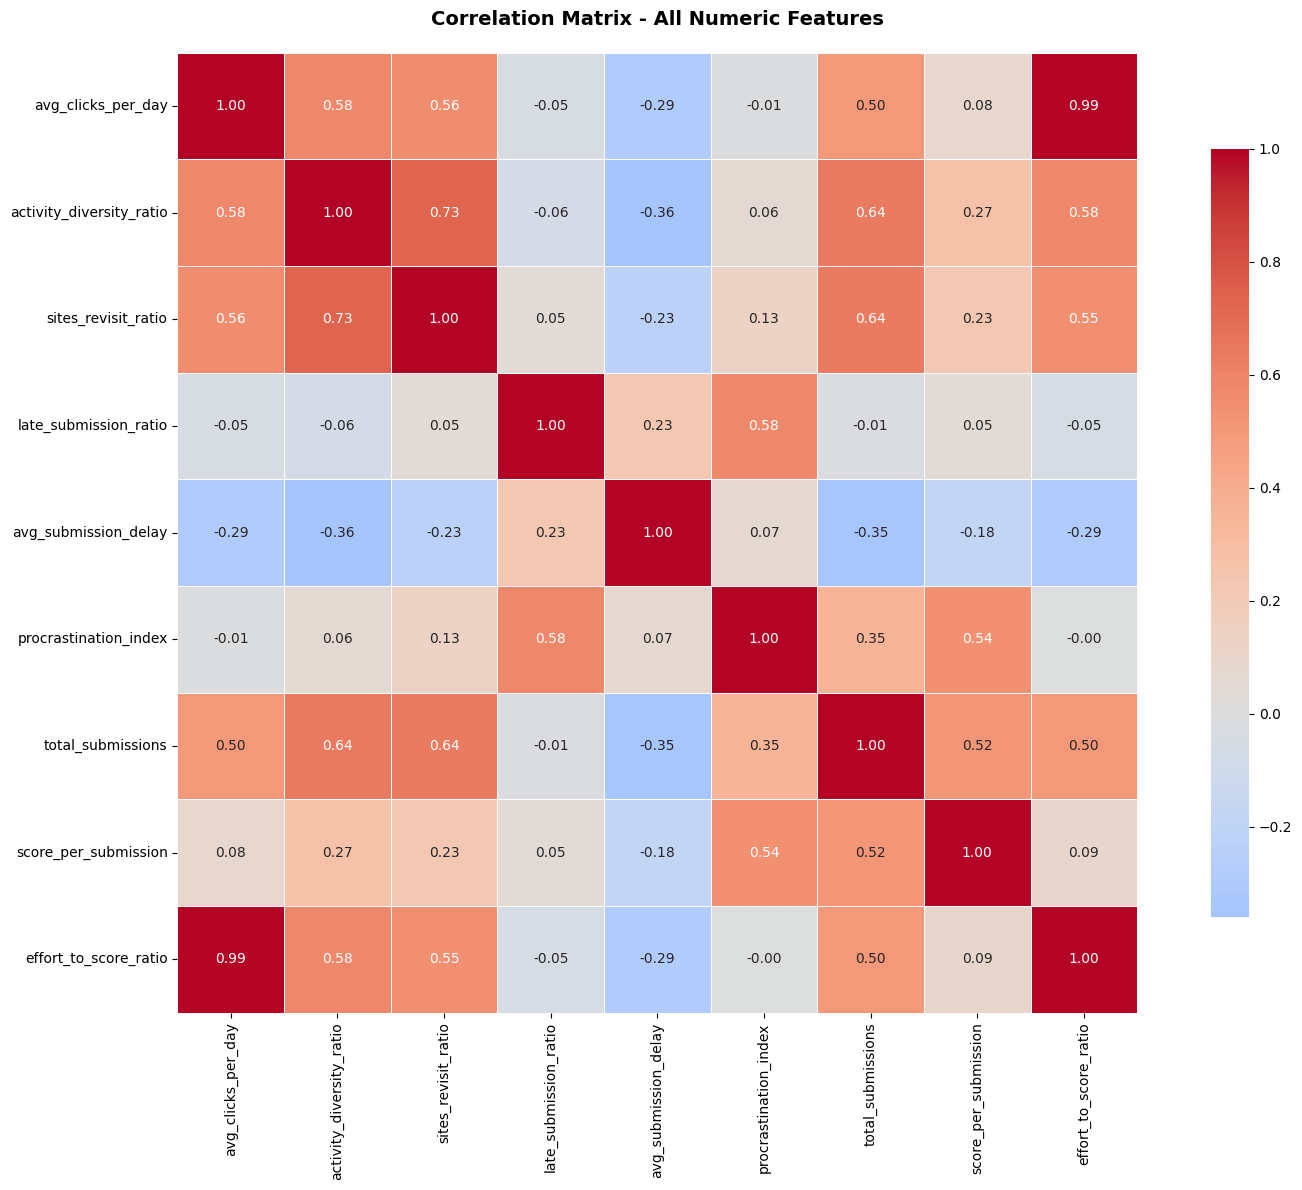

Heatmap generated successfully


In [6]:
# Calculate correlation matrix
correlation_matrix = df_numeric.corr(method='spearman')

# Create heatmap
fig, axes = plt.subplots(figsize=(16, 12))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
    ax=axes
)
plt.title('Correlation Matrix - All Numeric Features', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("Heatmap generated successfully")

In [7]:
# 1. Create a copy for MI analysis so we don't mess up the original df
from sklearn.calibration import LabelEncoder
from sklearn.feature_selection import mutual_info_classif


df_mi = df.copy()

# 2. Identify categorical columns that need encoding
categorical_cols = df_mi.select_dtypes(include=['object', 'string']).columns

# 3. Use LabelEncoder to turn strings into numbers
le = LabelEncoder()
for col in categorical_cols:
    df_mi[col] = le.fit_transform(df_mi[col].astype(str))

# 4. Define features (X) and targets (y)
# Ensure we drop the columns that act as 'answers' or are irrelevant
X = df_mi.drop(columns=['final_result'])
y_final = df_mi['final_result']

# 5. Run Mutual Information for Classification
# discrete_features=True tells the model these are categories
mi_scores = mutual_info_classif(X, y_final, discrete_features=True, random_state=42)

# 6. Organize and Display
mi_results = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)

print("="*40)
print("MUTUAL INFORMATION SCORES (Target: final_result)")
print(mi_results)

KeyError: "['final_result'] not found in axis"

## 2. BIRCH Clustering

BIRCH parameters:
- **threshold**: Maximum radius of a subcluster (controls cluster granularity)
- **branching_factor**: Maximum number of subclusters per node
- **n_clusters**: Final number of clusters


## 2.1 Finding Optimal Number of Clusters

Use Silhouette Score and Elbow Method to determine the best k value.


k=2: Silhouette=0.5853
k=3: Silhouette=0.6107
k=4: Silhouette=0.6418
k=5: Silhouette=0.6425
k=6: Silhouette=0.6689
k=7: Silhouette=0.6493
k=8: Silhouette=0.6533
k=9: Silhouette=0.6566
k=10: Silhouette=0.6033


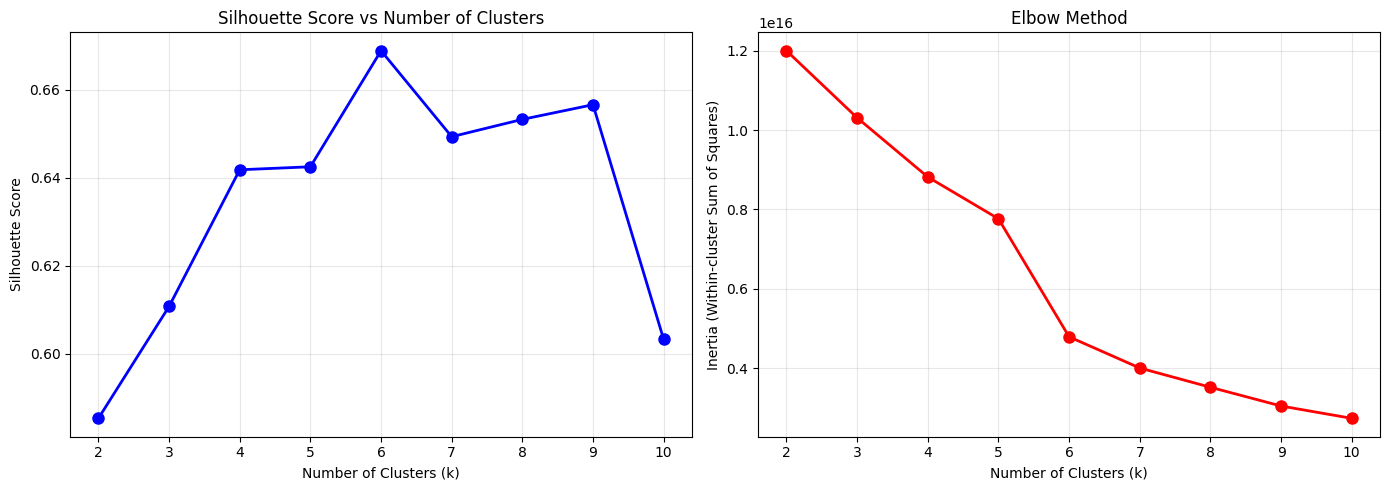


Best k based on Silhouette Score: 6


In [69]:
# Test different numbers of clusters
k_range = range(2, 11)
silhouette_scores = []
inertias = []

for k in k_range:
    birch_temp = Birch(threshold=0.5, branching_factor=50, n_clusters=k)
    labels_temp = birch_temp.fit_predict(df)
    
    silhouette_scores.append(silhouette_score(df, labels_temp))
    
    # Calculate inertia (within-cluster sum of squares)
    inertia = 0
    for i in range(k):
        cluster_points = df[labels_temp == i]
        if len(cluster_points) > 0:
            centroid = cluster_points.mean()
            inertia += ((cluster_points - centroid) ** 2).sum().sum()
    inertias.append(inertia)
    
    print(f"k={k}: Silhouette={silhouette_scores[-1]:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Silhouette Score Plot
axes[0].plot(k_range, silhouette_scores, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Silhouette Score')
axes[0].set_title('Silhouette Score vs Number of Clusters')
axes[0].set_xticks(list(k_range))
axes[0].grid(True, alpha=0.3)

# Elbow Plot
axes[1].plot(k_range, inertias, 'ro-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Inertia (Within-cluster Sum of Squares)')
axes[1].set_title('Elbow Method')
axes[1].set_xticks(list(k_range))
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Best k based on silhouette
best_k = k_range[np.argmax(silhouette_scores)]
print(f"\nBest k based on Silhouette Score: {best_k}")



## 2.2 Inplementing Clusters by using the specified k

In [70]:
# Initialize and fit BIRCH
birch = Birch(
    threshold=0.5,
    branching_factor=50,
    n_clusters=3  # Let BIRCH determine optimal subclusters first
)

# Fit and predict
cluster_labels = birch.fit_predict(df)

# Add cluster labels to dataframe
df_clustered = df.copy()
df_clustered['cluster'] = cluster_labels

print(f"Number of clusters found: {len(np.unique(cluster_labels))}")
print(f"\nCluster distribution:")
print(df_clustered['cluster'].value_counts().sort_index())


Number of clusters found: 3

Cluster distribution:
cluster
0    27789
1     3732
2     1027
Name: count, dtype: int64


## 3. Cluster Evaluation

Evaluate clustering quality using:
- **Silhouette Score**: Measures how similar points are to their own cluster vs other clusters (-1 to 1, higher is better)
- **Calinski-Harabasz Index**: Ratio of between-cluster to within-cluster variance (higher is better)
- **Davies-Bouldin Index**: Average similarity between clusters (lower is better)


In [71]:
# Calculate evaluation metrics
silhouette = silhouette_score(df, cluster_labels)
calinski = calinski_harabasz_score(df, cluster_labels)
davies = davies_bouldin_score(df, cluster_labels)

print("=" * 50)
print("CLUSTERING EVALUATION METRICS")
print("=" * 50)
print(f"\nSilhouette Score:        {silhouette:.4f}")
print(f"Calinski-Harabasz Index: {calinski:.4f}")
print(f"Davies-Bouldin Index:    {davies:.4f}")


CLUSTERING EVALUATION METRICS

Silhouette Score:        0.6107
Calinski-Harabasz Index: 9964.6156
Davies-Bouldin Index:    0.8762


## 4. Cluster Visualization

Use PCA to reduce dimensions for 2D visualization.


PCA explained variance ratio: [0.68372837 0.17313975]
Total variance explained: 85.69%


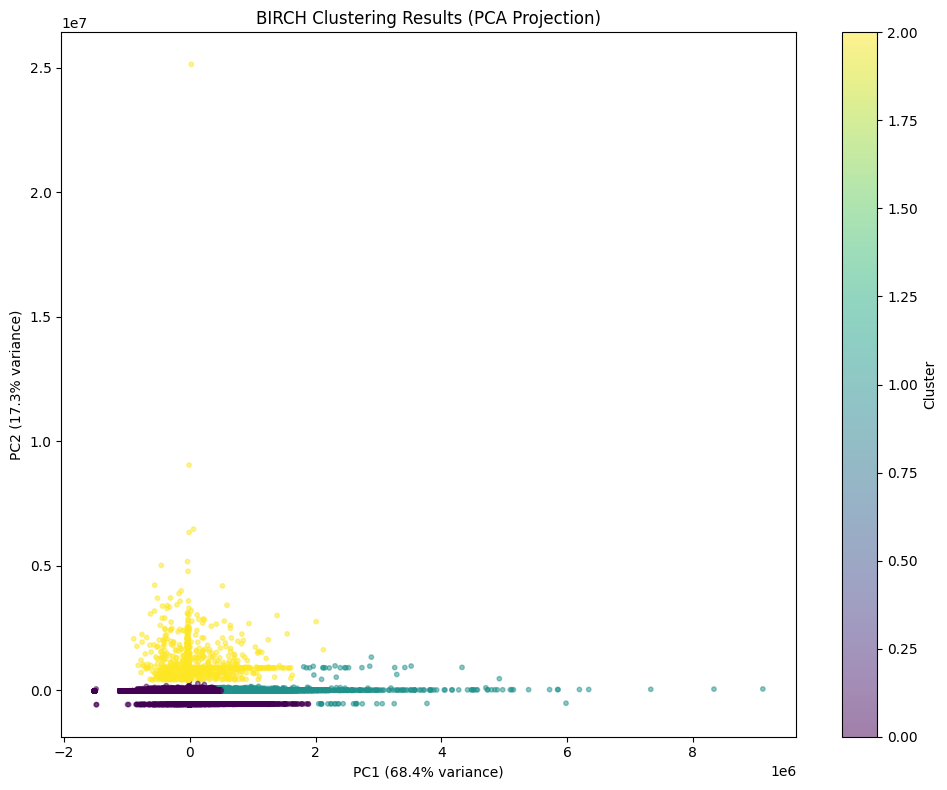

In [72]:
# Reduce to 2D using PCA
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df)

print(f"PCA explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total variance explained: {sum(pca.explained_variance_ratio_):.2%}")

# Plot clusters
plt.figure(figsize=(10, 8))
scatter = plt.scatter(df_pca[:, 0], df_pca[:, 1], 
                      c=cluster_labels, cmap='viridis', 
                      alpha=0.5, s=10)
plt.colorbar(scatter, label='Cluster')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.title('BIRCH Clustering Results (PCA Projection)')
plt.tight_layout()
plt.show()


PCA Loadings (Feature Contributions):
                            PC1    PC2
engagement_per_credit     0.999  0.008
score_per_submission      0.037  0.019
late_submission_ratio    -0.014  0.672
procrastination_index     0.002  0.740
avg_submission_delay     -0.000  0.000
effort_to_score_ratio     0.000  0.000
submissions_per_week      0.000  0.000
sites_revisit_ratio       0.000  0.000
activity_diversity_ratio  0.000 -0.000
total_submissions         0.000 -0.000
late_submissions_count    0.000  0.000
tma_cma_weighted_score    0.000 -0.000
num_of_prev_attempts     -0.000  0.000
studied_credits          -0.000  0.000
revision_intensity       -0.000 -0.000


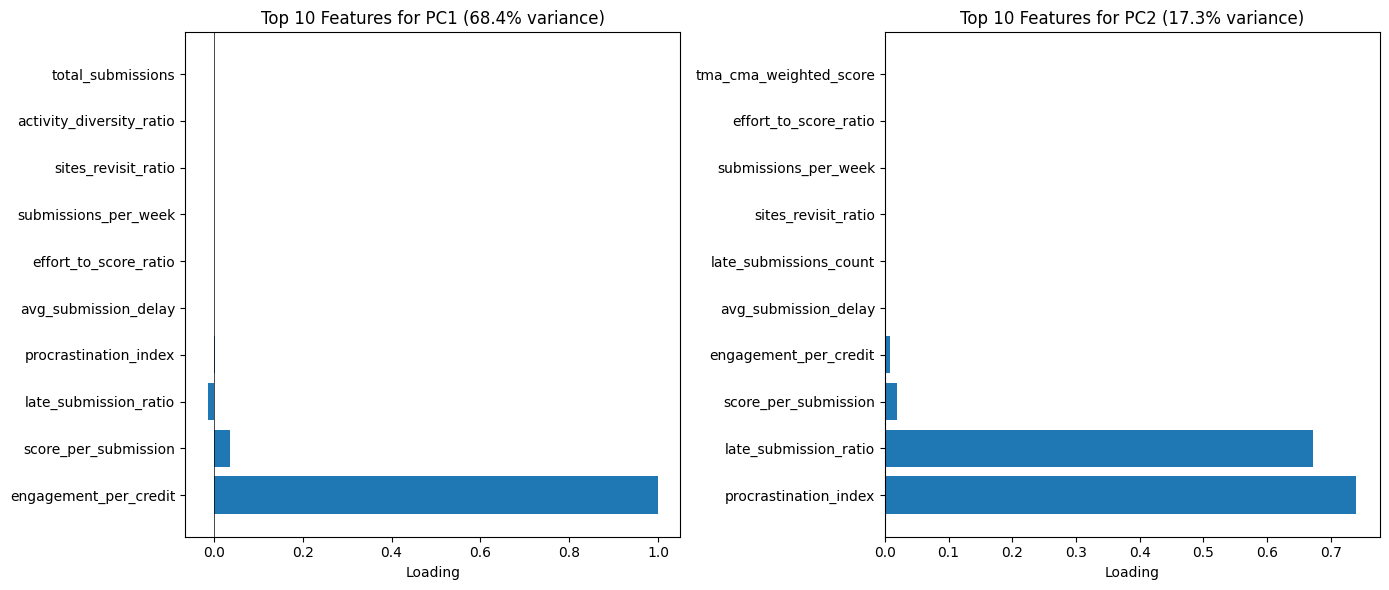

In [73]:
# Get PCA loadings (feature contributions to each PC)
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=df.columns
)

# Sort by absolute contribution to PC1
loadings['PC1_abs'] = loadings['PC1'].abs()
loadings_sorted = loadings.sort_values('PC1_abs', ascending=False).drop('PC1_abs', axis=1)

print("PCA Loadings (Feature Contributions):")
print(loadings_sorted.round(3))

# Plot top 10 features for each PC
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# PC1 loadings
top_pc1 = loadings['PC1'].abs().nlargest(10).index
axes[0].barh(range(10), loadings.loc[top_pc1, 'PC1'])
axes[0].set_yticks(range(10))
axes[0].set_yticklabels(top_pc1)
axes[0].set_xlabel('Loading')
axes[0].set_title(f'Top 10 Features for PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
axes[0].axvline(x=0, color='black', linewidth=0.5)

# PC2 loadings
top_pc2 = loadings['PC2'].abs().nlargest(10).index
axes[1].barh(range(10), loadings.loc[top_pc2, 'PC2'])
axes[1].set_yticks(range(10))
axes[1].set_yticklabels(top_pc2)
axes[1].set_xlabel('Loading')
axes[1].set_title(f'Top 10 Features for PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
axes[1].axvline(x=0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()


## 5. Cluster Profiling

Analyze the characteristics of each cluster by examining feature means.


In [74]:
# Calculate cluster statistics
cluster_stats = df_clustered.groupby('cluster').mean()

print("=" * 50)
print("CLUSTER PROFILES (Feature Means)")
print("=" * 50)
print(f"\nNumber of samples per cluster:")
print(df_clustered['cluster'].value_counts().sort_index())
print(f"\n")
cluster_stats.T


CLUSTER PROFILES (Feature Means)

Number of samples per cluster:
cluster
0    27789
1     3732
2     1027
Name: count, dtype: int64




cluster,0,1,2
engagement_per_credit,-117256.794059,1.073259e+06,1.115895e+05
tma_cma_weighted_score,0.355812,6.038234e-01,4.015637e-01
submissions_per_week,-0.468399,2.853990e-01,0.000000e+00
late_submissions_count,-0.046116,5.567455e-02,1.045523e+00
num_of_prev_attempts,0.019961,-1.480435e-01,-2.140071e-03
studied_credits,0.374369,0.000000e+00,2.834307e-01
revision_intensity,0.384023,7.735187e-01,2.103996e-01
activity_diversity_ratio,0.073882,4.889098e-01,3.645921e-01
sites_revisit_ratio,0.004039,6.908114e-01,4.230331e-01
late_submission_ratio,-34787.375830,5.798650e+03,1.045523e+06


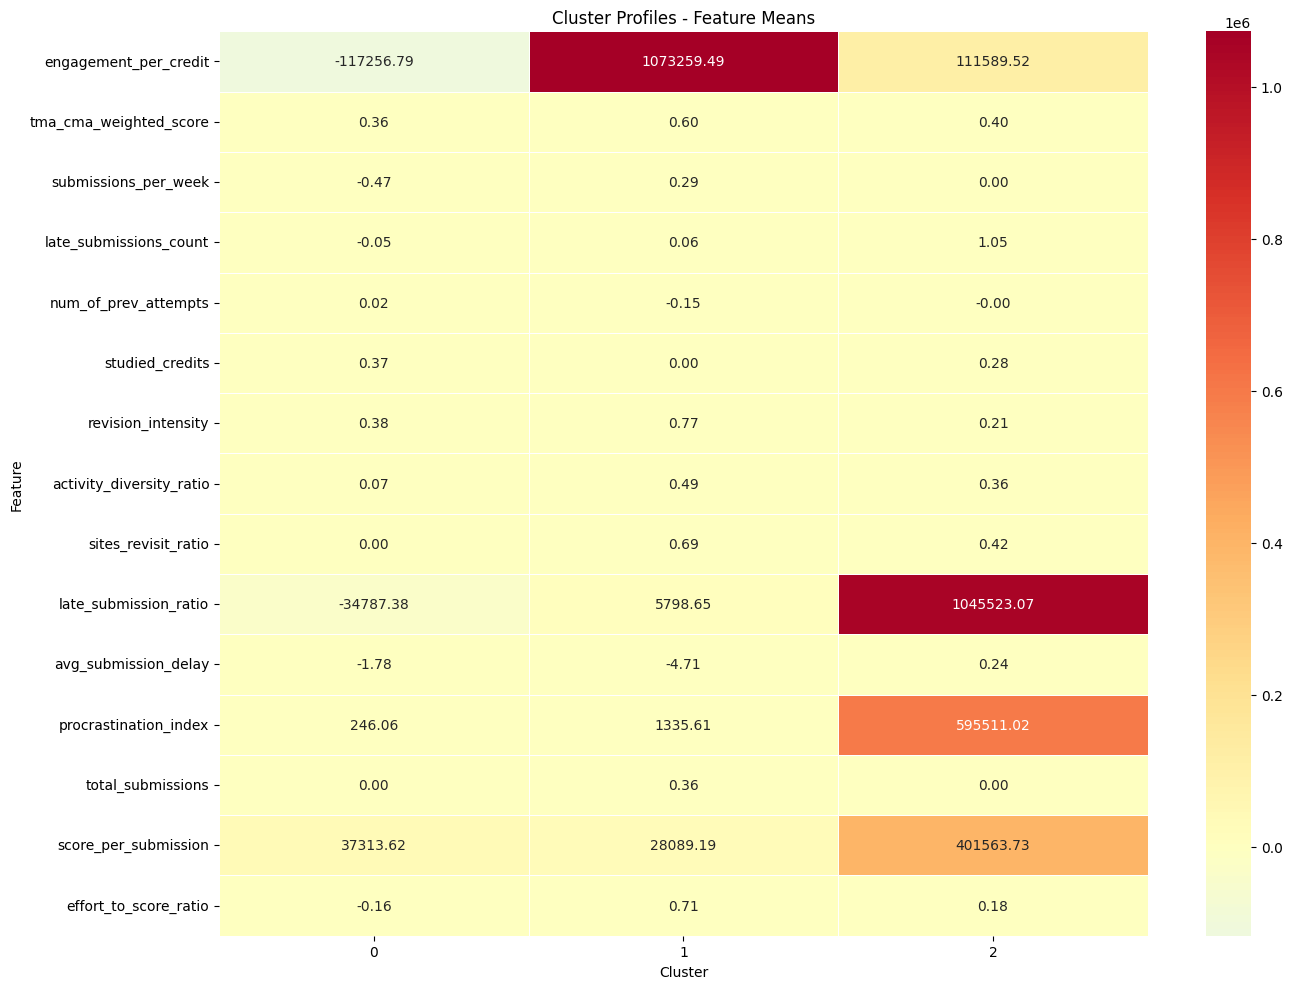

In [75]:
# Heatmap of cluster profiles
plt.figure(figsize=(14, 10))
sns.heatmap(cluster_stats.T, annot=True, fmt='.2f', cmap='RdYlBu_r', 
            center=0, linewidths=0.5)
plt.title('Cluster Profiles - Feature Means')
plt.xlabel('Cluster')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


Outcome Counts per Cluster:
final_result  Distinction  Fail  Pass  Withdrawn
cluster                                         
0                    2339  6205  9878       9367
1                     570   598  2014        550
2                     115   244   468        200

Outcome Rates (%) per Cluster:
final_result  Distinction   Fail   Pass  Withdrawn
cluster                                           
0                    8.42  22.33  35.55      33.71
1                   15.27  16.02  53.97      14.74
2                   11.20  23.76  45.57      19.47


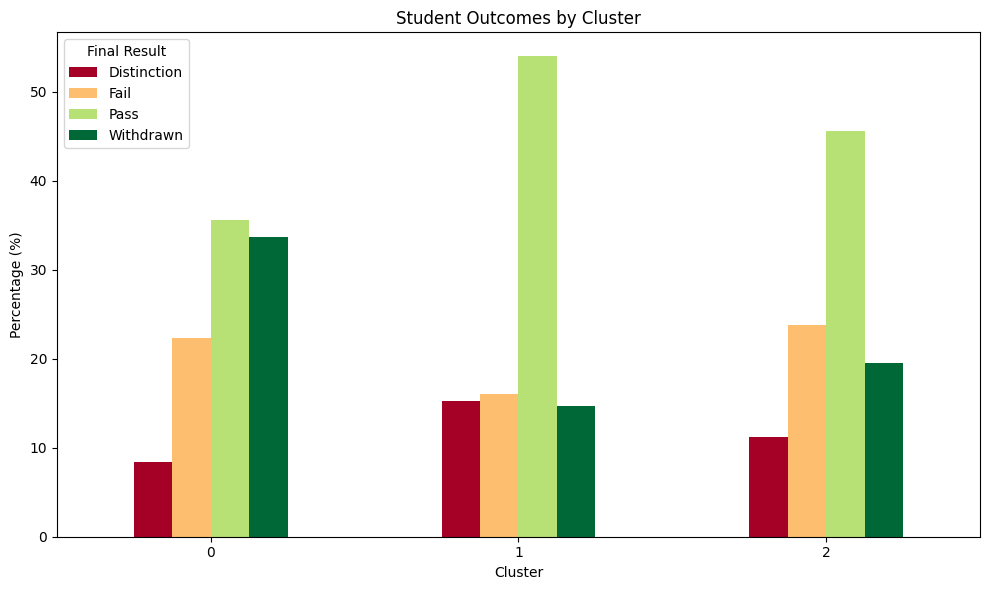


Cluster 0:
  Total students: 27789
  Distinction: 8.4%
  Fail: 22.3%
  Pass: 35.5%
  Withdrawn: 33.7%

Cluster 1:
  Total students: 3732
  Distinction: 15.3%
  Fail: 16.0%
  Pass: 54.0%
  Withdrawn: 14.7%

Cluster 2:
  Total students: 1027
  Distinction: 11.2%
  Fail: 23.8%
  Pass: 45.6%
  Withdrawn: 19.5%
Simplified Outcome Counts per Cluster:
outcome_simplified   Pass  Fail  Withdrawn
cluster                                   
0                   12217  6205       9367
1                    2584   598        550
2                     583   244        200

Simplified Outcome Rates (%) per Cluster:
outcome_simplified   Pass   Fail  Withdrawn
cluster                                    
0                   43.96  22.33      33.71
1                   69.24  16.02      14.74
2                   56.77  23.76      19.47


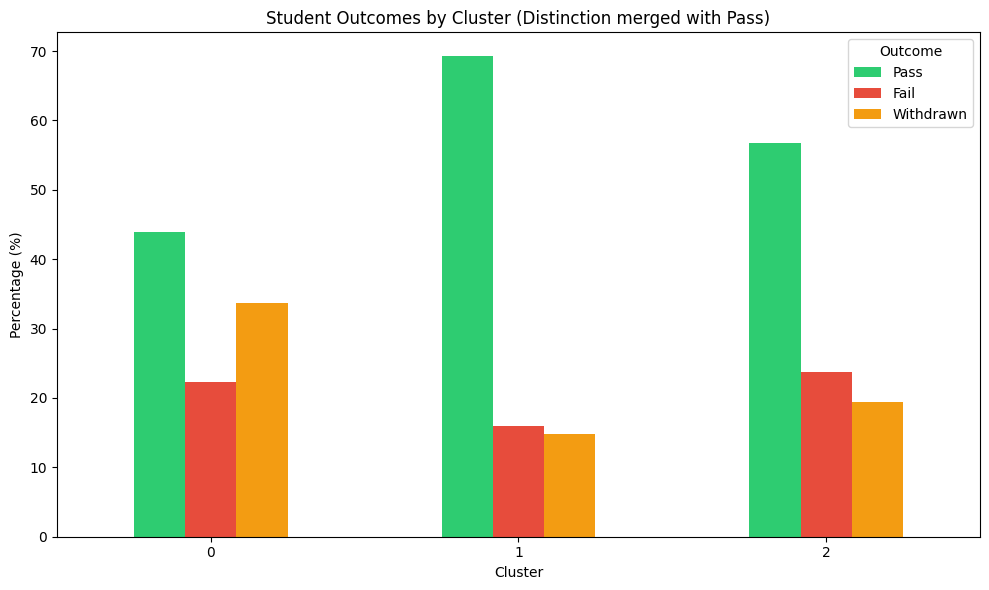


Cluster 0 (n=27789):
  Pass: 44.0%
  Fail: 22.3%
  Withdrawn: 33.7%

Cluster 1 (n=3732):
  Pass: 69.2%
  Fail: 16.0%
  Withdrawn: 14.7%

Cluster 2 (n=1027):
  Pass: 56.8%
  Fail: 23.8%
  Withdrawn: 19.5%


In [76]:
# Load original data with final_result
original_df = pd.read_csv('../data/merged/merged_1.csv')

# Add cluster labels to original data
original_df['cluster'] = cluster_labels

# Cross-tabulation: cluster vs final_result
outcome_counts = pd.crosstab(original_df['cluster'], original_df['final_result'])
outcome_rates = pd.crosstab(original_df['cluster'], original_df['final_result'], normalize='index') * 100

print("Outcome Counts per Cluster:")
print(outcome_counts)
print("\nOutcome Rates (%) per Cluster:")
print(outcome_rates.round(2))

# Plot outcome rates
outcome_rates.plot(kind='bar', figsize=(10, 6), colormap='RdYlGn')
plt.title('Student Outcomes by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Percentage (%)')
plt.legend(title='Final Result')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Summary
for cluster in sorted(original_df['cluster'].unique()):
    print(f"\nCluster {cluster}:")
    print(f"  Total students: {len(original_df[original_df['cluster'] == cluster])}")
    for outcome in outcome_rates.columns:
        rate = outcome_rates.loc[cluster, outcome]
        print(f"  {outcome}: {rate:.1f}%")




# Create simplified outcome (merge Distinction + Pass)
original_df['outcome_simplified'] = original_df['final_result'].replace({
    'Distinction': 'Pass',
    'Pass': 'Pass',
    'Fail': 'Fail',
    'Withdrawn': 'Withdrawn'
})

# Cross-tabulation with simplified outcomes
outcome_counts_simple = pd.crosstab(original_df['cluster'], original_df['outcome_simplified'])
outcome_rates_simple = pd.crosstab(original_df['cluster'], original_df['outcome_simplified'], normalize='index') * 100

# Reorder columns
col_order = ['Pass', 'Fail', 'Withdrawn']
outcome_counts_simple = outcome_counts_simple[col_order]
outcome_rates_simple = outcome_rates_simple[col_order]

print("Simplified Outcome Counts per Cluster:")
print(outcome_counts_simple)
print("\nSimplified Outcome Rates (%) per Cluster:")
print(outcome_rates_simple.round(2))

# Plot simplified outcome rates
colors = ['#2ecc71', '#e74c3c', '#f39c12']  # Green, Red, Orange
outcome_rates_simple.plot(kind='bar', figsize=(10, 6), color=colors)
plt.title('Student Outcomes by Cluster (Distinction merged with Pass)')
plt.xlabel('Cluster')
plt.ylabel('Percentage (%)')
plt.legend(title='Outcome')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Summary
for cluster in sorted(original_df['cluster'].unique()):
    print(f"\nCluster {cluster} (n={len(original_df[original_df['cluster'] == cluster])}):")
    for outcome in col_order:
        rate = outcome_rates_simple.loc[cluster, outcome]
        print(f"  {outcome}: {rate:.1f}%")



## 6. Export Results

Save clustered data for further analysis.


In [77]:
# Save clustered dataset
OUTPUT_PATH = '../data/final/clustered_birch.csv'
df_clustered.to_csv(OUTPUT_PATH, index=False)

print(f"Clustered data saved to: {OUTPUT_PATH}")

# Summary
print("\n" + "=" * 50)
print("BIRCH CLUSTERING SUMMARY")
print("=" * 50)
print(f"\nDataset: {df.shape[0]} samples, {df.shape[1]} features")
print(f"Clusters found: {len(np.unique(cluster_labels))}")
print(f"\nModel parameters:")
print(f"  - threshold: {birch.threshold}")
print(f"  - branching_factor: {birch.branching_factor}")
print(f"\nEvaluation:")
print(f"  - Silhouette Score: {silhouette:.4f}")
print(f"  - Calinski-Harabasz: {calinski:.4f}")
print(f"  - Davies-Bouldin: {davies:.4f}")


Clustered data saved to: ../data/final/clustered_birch.csv

BIRCH CLUSTERING SUMMARY

Dataset: 32548 samples, 15 features
Clusters found: 3

Model parameters:
  - threshold: 0.5
  - branching_factor: 50

Evaluation:
  - Silhouette Score: 0.6107
  - Calinski-Harabasz: 9964.6156
  - Davies-Bouldin: 0.8762
